In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

In [2]:
DATA_DIR = Path("c:\\Users\\Niraj Mhatre\\projects\\motor_insurance_data\\Fast_Furious_Insured")

TRAIN_CSV = DATA_DIR / "train.csv"
TEST_CSV = DATA_DIR / "test.csv"

TRAIN_IMG_DIR = DATA_DIR / "trainImages"
TEST_IMG_DIR = DATA_DIR / "testImages"

In [3]:
train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)

train_df.head()

,Image_path,Insurance_company,Cost_of_vehicle,Min_coverage,Expiry_date,Max_coverage,Condition,Amount
0,img_4513976.jpg,BQ,41500.0,1037.5,2026-12-03,36142.68,0,0.0
1,img_7764995.jpg,BQ,50700.0,1267.5,2025-07-10,12753.00,1,6194.0
2,img_451308.jpg,A,49500.0,1237.5,2022-08-11,43102.68,0,0.0
3,img_7768372.jpg,A,33500.0,837.5,2022-08-02,8453.00,1,7699.0
4,img_7765274.jpg,AC,27600.0,690.0,2026-05-01,6978.00,1,8849.0


In [4]:
def get_image_info(image_path):
    try:
        with Image.open(image_path) as img:
            return {
                "width": img.width,
                "height": img.height,
                "mode": img.mode,
                "format": img.format,
                "aspect_ratio": img.width / img.height
            }
    except Exception:
        return None

In [5]:
image_info = []

for image_name in train_df["Image_path"]:
    
    image_path = TRAIN_IMG_DIR / image_name
    
    info = get_image_info(image_path)
    
    if info is not None:
        info["Image_path"] = image_name
        image_info.append(info)

image_info_df = pd.DataFrame(image_info)

image_info_df.head()

,width,height,mode,format,aspect_ratio,Image_path
0,630,418,RGB,JPEG,1.507177,img_4513976.jpg
1,276,183,RGB,JPEG,1.508197,img_7764995.jpg
2,750,563,RGB,JPEG,1.332149,img_451308.jpg
3,1024,682,RGB,JPEG,1.501466,img_7768372.jpg
4,678,381,RGB,JPEG,1.779528,img_7765274.jpg


In [6]:
image_info_df[
    ["width", "height", "aspect_ratio"]
].describe()

,width,height,aspect_ratio
count,1399.000000,1399.000000,1399.000000
mean,599.487491,396.537527,1.568142
std,529.688154,381.151273,0.362607
min,92.000000,69.000000,0.560000
25%,275.000000,183.000000,1.364583
50%,311.000000,200.000000,1.502732
75%,800.000000,510.000000,1.714286
max,4500.000000,4032.000000,3.379538


In [7]:
image_info_df["format"].value_counts()

format
JPEG    1399
Name: count, dtype: int64

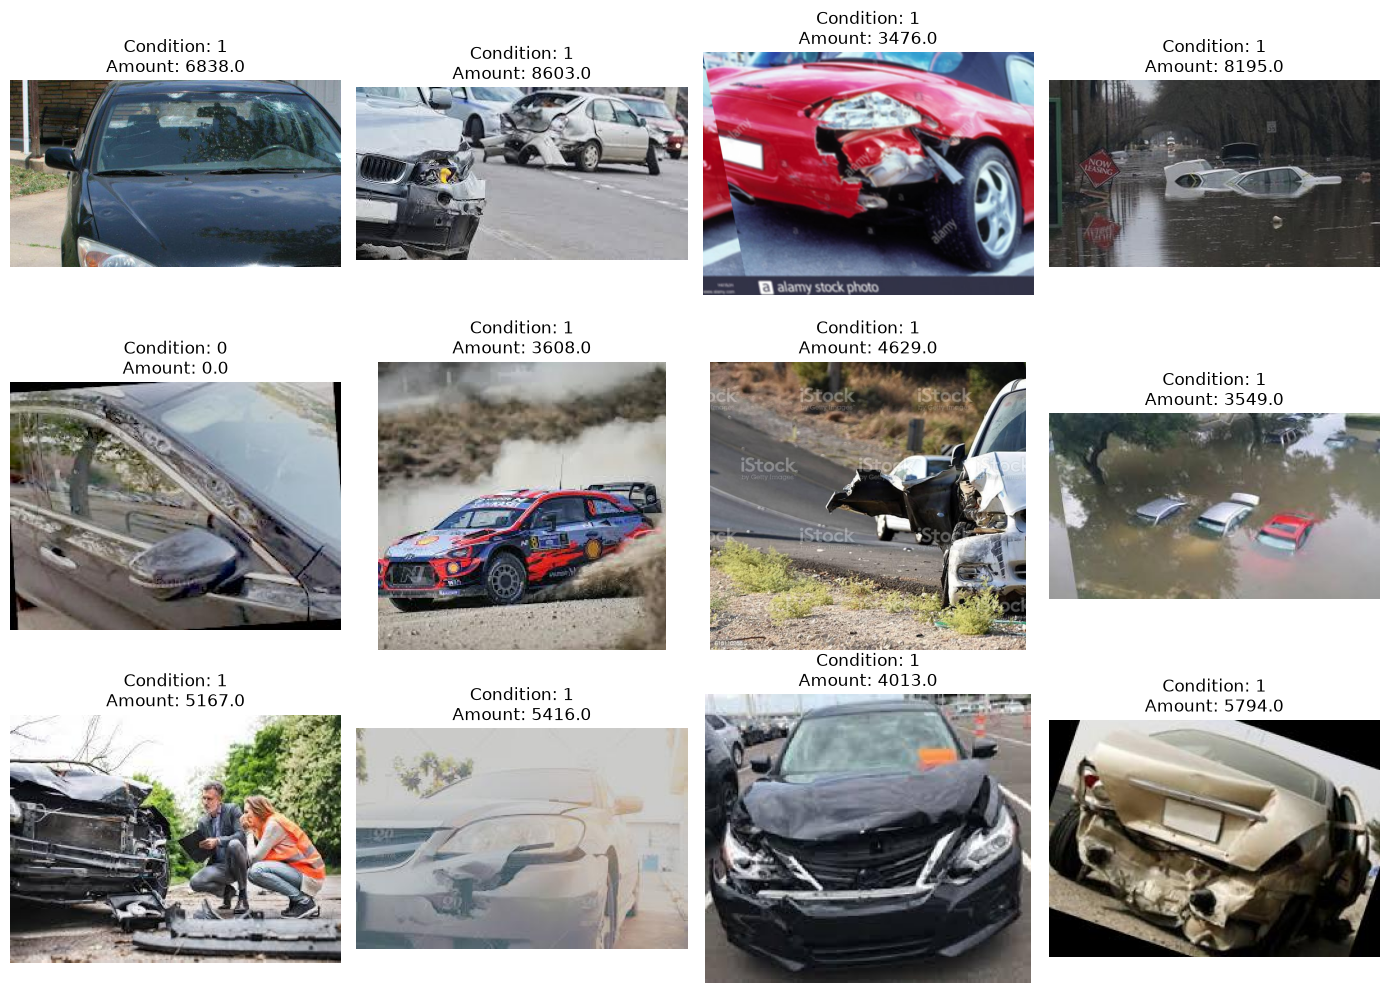

In [8]:
sample_df = train_df.sample(12, random_state=42)

fig, axes = plt.subplots(
    3, 4,
    figsize=(14, 10)
)

for ax, (_, row) in zip(axes.flat, sample_df.iterrows()):
    
    image_path = TRAIN_IMG_DIR / row["Image_path"]
    
    image = Image.open(image_path).convert("RGB")
    
    ax.imshow(image)
    ax.axis("off")
    
    ax.set_title(
        f"Condition: {row['Condition']}\n"
        f"Amount: {row['Amount']}"
    )

plt.tight_layout()
plt.show()

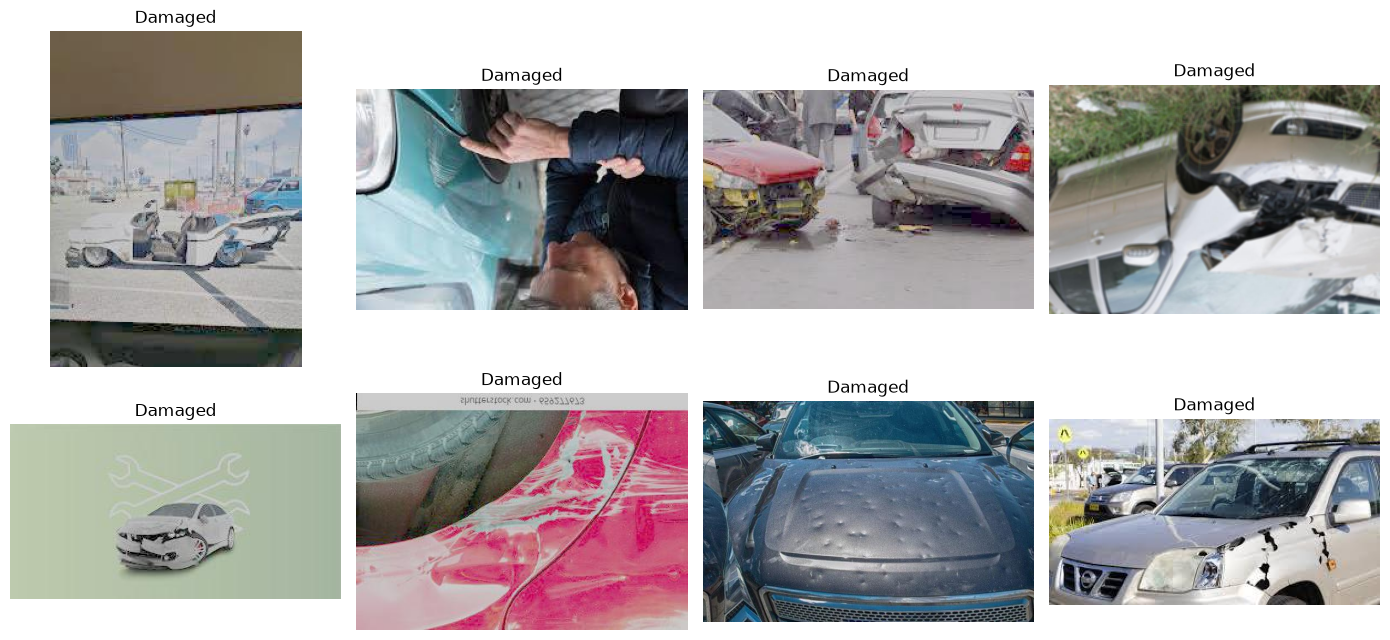

In [9]:
damaged_df = train_df[
    train_df["Condition"] == 1
].sample(8, random_state=42)

fig, axes = plt.subplots(
    2, 4,
    figsize=(14, 7)
)

for ax, (_, row) in zip(axes.flat, damaged_df.iterrows()):
    
    image_path = TRAIN_IMG_DIR / row["Image_path"]
    image = Image.open(image_path).convert("RGB")
    
    ax.imshow(image)
    ax.axis("off")
    ax.set_title("Damaged")

plt.tight_layout()
plt.show()

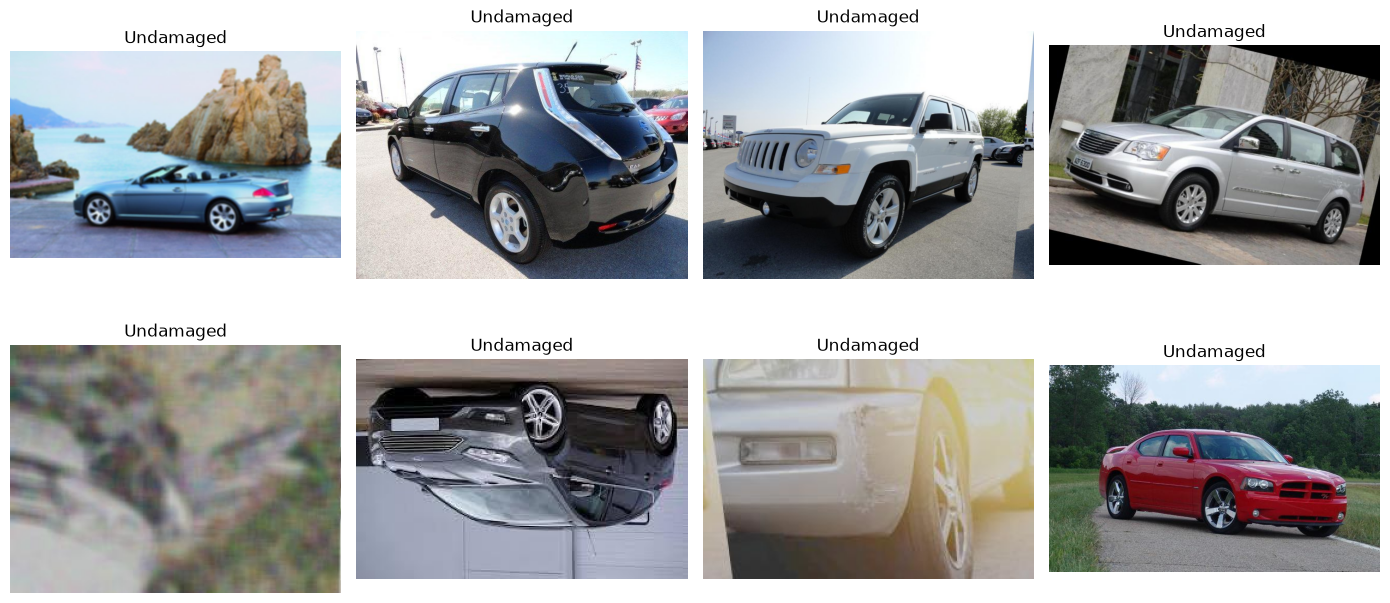

In [10]:
undamaged_df = train_df[
    train_df["Condition"] == 0
].sample(8, random_state=42)

fig, axes = plt.subplots(
    2, 4,
    figsize=(14, 7)
)

for ax, (_, row) in zip(axes.flat, undamaged_df.iterrows()):
    
    image_path = TRAIN_IMG_DIR / row["Image_path"]
    image = Image.open(image_path).convert("RGB")
    
    ax.imshow(image)
    ax.axis("off")
    ax.set_title("Undamaged")

plt.tight_layout()
plt.show()

In [11]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [12]:
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [13]:
class VehicleDamageDataset(Dataset):
    
    def __init__(self, dataframe, image_dir, transform=None):
        
        self.dataframe = dataframe.reset_index(drop=True)
        self.image_dir = Path(image_dir)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        
        row = self.dataframe.iloc[index]
        
        image_path = self.image_dir / row["Image_path"]
        
        image = Image.open(image_path).convert("RGB")
        
        label = int(row["Condition"])
        
        if self.transform:
            image = self.transform(image)
        
        return image, label

In [14]:
from sklearn.model_selection import train_test_split
train_data, val_data = train_test_split(
    train_df,
    test_size=0.2,
    random_state=42,
    stratify=train_df["Condition"]
)

In [15]:
print("Training samples:", len(train_data))
print("Validation samples:", len(val_data))

Training samples: 1119
Validation samples: 280


In [16]:
print("Training distribution:")
print(train_data["Condition"].value_counts(normalize=True))

Training distribution:
Condition
1    0.929401
0    0.070599
Name: proportion, dtype: float64


In [17]:
train_dataset = VehicleDamageDataset(
    dataframe=train_data,
    image_dir=TRAIN_IMG_DIR,
    transform=train_transform
)

val_dataset = VehicleDamageDataset(
    dataframe=val_data,
    image_dir=TRAIN_IMG_DIR,
    transform=val_transform
)

In [18]:
image, label = train_dataset[0]

print("Image shape:", image.shape)
print("Label:", label)

Image shape: torch.Size([3, 224, 224])
Label: 1


In [19]:
def denormalize(image_tensor):
    
    mean = torch.tensor(
        [0.485, 0.456, 0.406]
    ).view(3, 1, 1)
    
    std = torch.tensor(
        [0.229, 0.224, 0.225]
    ).view(3, 1, 1)
    
    image = image_tensor * std + mean
    
    return image.clamp(0, 1)

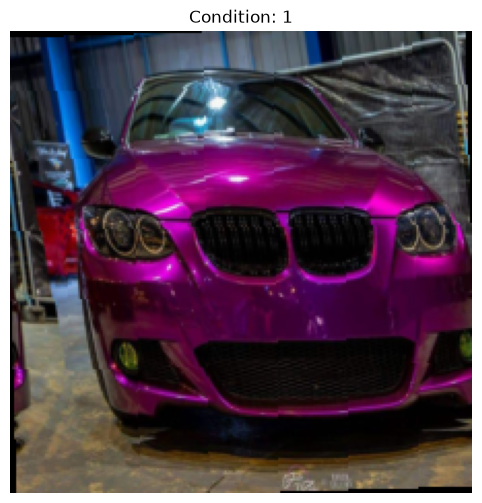

In [20]:
image, label = train_dataset[0]

display_image = denormalize(image)

plt.figure(figsize=(6, 6))

plt.imshow(display_image.permute(1, 2, 0))

plt.title(f"Condition: {label}")
plt.axis("off")

plt.show()

In [21]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

In [22]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0
)
images, labels = next(iter(train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)

Images shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])


In [23]:
unique, counts = torch.unique(
    labels,
    return_counts=True
)

dict(zip(unique.tolist(), counts.tolist()))

{0: 3, 1: 29}

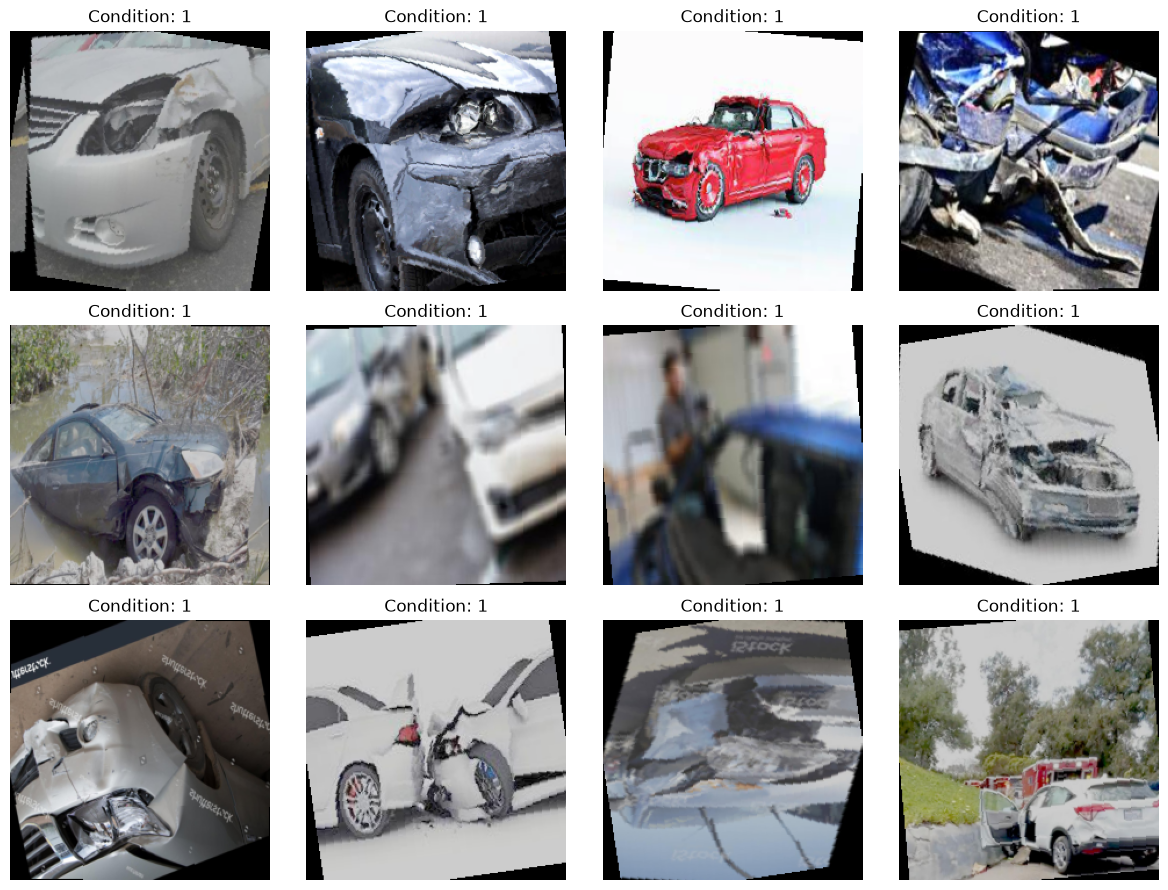

In [24]:
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(
    3, 4,
    figsize=(12, 9)
)

for ax, image, label in zip(
    axes.flat,
    images[:12],
    labels[:12]
):
    
    image = denormalize(image)
    
    ax.imshow(image.permute(1, 2, 0))
    ax.set_title(f"Condition: {label.item()}")
    ax.axis("off")

plt.tight_layout()
plt.show()